# Spectral Noise Injection for Adversarial Robustness

This notebook implements the physical corruption stage from the homr adversarial robustness protocol. It focuses on FFT-based colored noise generation, clipping to the image domain, validation checks, and a small epsilon-grid sweep scaffold that can be connected to a real attack and model later.

In [19]:
from __future__ import annotations

from dataclasses import dataclass, asdict
from pathlib import Path
from typing import Any, Callable

import math
import random

import numpy as np

try:
    import torch
except Exception:
    torch = None

try:
    import matplotlib.pyplot as plt
except Exception:
    plt = None

try:
    import pandas as pd
except Exception:
    pd = None


GLOBAL_DTYPE = np.float32
DEVICE = "cpu"
SEED = 42

WORKSPACE_ROOT = next((parent for parent in [Path.cwd(), *Path.cwd().parents] if (parent / "pyproject.toml").exists()), Path.cwd())
DATASET_ROOT = WORKSPACE_ROOT / "dataset"
IMAGE_ROOT = DATASET_ROOT / "images"
MXL_ROOT = DATASET_ROOT / "mxl"
ATTACK_ARTIFACT_ROOT = WORKSPACE_ROOT / "attacks" / "artifacts" / "spectral_noise_injection"
POISONED_IMAGE_ROOT = ATTACK_ARTIFACT_ROOT / "poisoned_images"
PREDICTED_XML_ROOT = ATTACK_ARTIFACT_ROOT / "predicted_xml"
SUPPORTED_IMAGE_SUFFIXES = {".png", ".jpg", ".jpeg", ".bmp", ".tif", ".tiff", ".webp"}
SUPPORTED_XML_SUFFIXES = {".xml", ".musicxml"}
RUN_NOTEBOOK_DEMO = False

np.random.seed(SEED)
random.seed(SEED)
if torch is not None:
    torch.manual_seed(SEED)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(SEED)


@dataclass(frozen=True)
class SpectralNoiseConfig:
    alpha: float = 1.0
    eta: float = 1e-6
    epsilon_num: float = 1e-12
    epsilon_phys_grid: tuple[float, ...] = (0.0, 0.1, 0.2, 0.3, 0.4, 0.5)
    epsilon_math_grid: tuple[float, ...] = (0.0, 0.25 / 255, 0.5 / 255, 1 / 255, 2 / 255, 4 / 255)
    image_size: tuple[int, int] = (192, 256)
    white_noise_scale: float = 1.0
    default_batch_size: int = 2


CONFIG = SpectralNoiseConfig()

print(asdict(CONFIG))
print({"dataset_root": str(DATASET_ROOT), "image_root": str(IMAGE_ROOT), "poisoned_root": str(POISONED_IMAGE_ROOT)})

{'alpha': 1.0, 'eta': 1e-06, 'epsilon_num': 1e-12, 'epsilon_phys_grid': (0.0, 0.1, 0.2, 0.3, 0.4, 0.5), 'epsilon_math_grid': (0.0, 0.000980392156862745, 0.00196078431372549, 0.00392156862745098, 0.00784313725490196, 0.01568627450980392), 'image_size': (192, 256), 'white_noise_scale': 1.0, 'default_batch_size': 2}
{'dataset_root': 'd:\\Users\\theda\\Documents\\dev\\Projects\\Uni\\Semester 4\\Artificial Intelligence\\Synesthesia\\dataset', 'image_root': 'd:\\Users\\theda\\Documents\\dev\\Projects\\Uni\\Semester 4\\Artificial Intelligence\\Synesthesia\\dataset\\images', 'poisoned_root': 'd:\\Users\\theda\\Documents\\dev\\Projects\\Uni\\Semester 4\\Artificial Intelligence\\Synesthesia\\attacks\\artifacts\\spectral_noise_injection\\poisoned_images'}


## 2. Load Sample Score Image Tensors and Normalize to [0, 1]

In [3]:
def ensure_4d(array: np.ndarray) -> tuple[np.ndarray, bool]:
    array = np.asarray(array, dtype=GLOBAL_DTYPE)
    if array.ndim == 2:
        return array[None, None, :, :], True
    if array.ndim == 3:
        return array[None, :, :, :], True
    if array.ndim == 4:
        return array, False
    raise ValueError(f"Expected a 2D, 3D, or 4D tensor, got shape {array.shape}")


def restore_shape(array: np.ndarray, squeezed: bool) -> np.ndarray:
    if not squeezed:
        return array
    if array.shape[0] != 1:
        return array
    if array.shape[1] == 1:
        return array[0, 0]
    return array[0]


def normalize_to_unit_interval(array: np.ndarray) -> np.ndarray:
    array = np.asarray(array, dtype=GLOBAL_DTYPE)
    array = np.nan_to_num(array, nan=0.0, posinf=1.0, neginf=0.0)
    min_value = float(array.min())
    max_value = float(array.max())
    if math.isclose(max_value, min_value):
        return np.zeros_like(array, dtype=GLOBAL_DTYPE)
    normalized = (array - min_value) / (max_value - min_value)
    return np.clip(normalized, 0.0, 1.0).astype(GLOBAL_DTYPE)


def load_image_tensor(path: str | Path) -> np.ndarray:
    from PIL import Image

    image = Image.open(path).convert("L")
    array = np.asarray(image, dtype=GLOBAL_DTYPE) / 255.0
    return array[None, :, :]


def make_sample_score_tensor(height: int = 192, width: int = 256, channels: int = 1) -> np.ndarray:
    y = np.linspace(0.0, 1.0, height, dtype=GLOBAL_DTYPE)
    x = np.linspace(0.0, 1.0, width, dtype=GLOBAL_DTYPE)
    yy, xx = np.meshgrid(y, x, indexing="ij")
    base = 0.55 * yy + 0.25 * np.sin(8 * np.pi * xx) * np.cos(6 * np.pi * yy)
    base = normalize_to_unit_interval(base)
    if channels == 1:
        return base[None, :, :]
    return np.repeat(base[None, :, :], channels, axis=0)


sample_tensor = make_sample_score_tensor(*CONFIG.image_size)
print(sample_tensor.shape, float(sample_tensor.min()), float(sample_tensor.max()))

(1, 192, 256) 0.0 1.0


## 3. Build Frequency Grids for 2D FFT Filtering

In [4]:
def build_frequency_grid(height: int, width: int, centered: bool = False) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    fy = np.fft.fftfreq(height)
    fx = np.fft.fftfreq(width)
    if centered:
        fy = np.fft.fftshift(fy)
        fx = np.fft.fftshift(fx)
    uu, vv = np.meshgrid(fy, fx, indexing="ij")
    radial = np.sqrt(uu * uu + vv * vv)
    return uu.astype(GLOBAL_DTYPE), vv.astype(GLOBAL_DTYPE), radial.astype(GLOBAL_DTYPE)


def stabilize_frequency_response(radial_frequency: np.ndarray, eta: float) -> np.ndarray:
    return np.maximum(radial_frequency, eta).astype(GLOBAL_DTYPE)


u_grid, v_grid, radial_grid = build_frequency_grid(*CONFIG.image_size)
print(u_grid.shape, v_grid.shape, radial_grid.min(), radial_grid.max())

(192, 256) (192, 256) 0.0 0.70710677


## 4. Implement Spectral (Colored) Noise Generator

In [5]:
def spectral_noise_generator(
    shape: tuple[int, int] | tuple[int, int, int] | tuple[int, int, int, int],
    alpha: float = 1.0,
    eta: float = 1e-6,
    epsilon_num: float = 1e-12,
    white_noise_scale: float = 1.0,
    rng: np.random.Generator | None = None,
) -> np.ndarray:
    rng = np.random.default_rng(SEED) if rng is None else rng
    shape = tuple(int(dim) for dim in shape)

    if len(shape) == 2:
        batch_shape: tuple[int, ...] = ()
        channels = 1
        height, width = shape
    elif len(shape) == 3:
        batch_shape = ()
        channels, height, width = shape
    elif len(shape) == 4:
        batch_shape = (shape[0],)
        channels, height, width = shape[1:]
    else:
        raise ValueError(f"Unsupported shape: {shape}")

    radial = build_frequency_grid(height, width, centered=False)[2]
    stabilized = stabilize_frequency_response(radial, eta=eta)
    filter_response = stabilized ** (-alpha)

    noise_shape = (*batch_shape, channels, height, width)
    white_noise = rng.normal(loc=0.0, scale=white_noise_scale, size=noise_shape).astype(GLOBAL_DTYPE)
    if len(shape) == 2:
        white_noise = white_noise[None, None, :, :]
    elif len(shape) == 3:
        white_noise = white_noise[None, :, :, :]

    spectra = np.fft.fft2(white_noise, axes=(-2, -1))
    filtered_spectra = spectra * filter_response[None, None, :, :]
    correlated_noise = np.fft.ifft2(filtered_spectra, axes=(-2, -1)).real.astype(GLOBAL_DTYPE)
    correlated_noise = correlated_noise - correlated_noise.mean(axis=(-2, -1), keepdims=True)
    scale = np.std(correlated_noise, axis=(-2, -1), keepdims=True)
    correlated_noise = correlated_noise / (scale + epsilon_num)
    correlated_noise = np.nan_to_num(correlated_noise, nan=0.0, posinf=0.0, neginf=0.0)
    return correlated_noise


pink_noise = spectral_noise_generator((1, *CONFIG.image_size), alpha=1.0, eta=CONFIG.eta)
brown_noise = spectral_noise_generator((1, *CONFIG.image_size), alpha=2.0, eta=CONFIG.eta)
print(pink_noise.shape, float(pink_noise.min()), float(pink_noise.max()))

(1, 1, 192, 256) -3.4362735748291016 3.6720759868621826


## 5. Implement Spectral Noise Injection C(X; epsilon_phys)

In [6]:
def spectral_noise_injection(
    x: np.ndarray,
    epsilon_phys: float,
    alpha: float = 1.0,
    eta: float = 1e-6,
    epsilon_num: float = 1e-12,
    white_noise_scale: float = 1.0,
    rng: np.random.Generator | None = None,
    per_sample_noise: bool = True,
) -> np.ndarray:
    x_4d, squeezed = ensure_4d(x)
    rng = np.random.default_rng(SEED) if rng is None else rng

    if epsilon_phys == 0.0:
        return restore_shape(x_4d.copy(), squeezed)

    if per_sample_noise:
        noise = spectral_noise_generator(
            x_4d.shape,
            alpha=alpha,
            eta=eta,
            epsilon_num=epsilon_num,
            white_noise_scale=white_noise_scale,
            rng=rng,
        )
    else:
        shared_noise = spectral_noise_generator(
            (x_4d.shape[1], x_4d.shape[2], x_4d.shape[3]),
            alpha=alpha,
            eta=eta,
            epsilon_num=epsilon_num,
            white_noise_scale=white_noise_scale,
            rng=rng,
        )
        noise = np.repeat(shared_noise[None, :, :, :], x_4d.shape[0], axis=0)

    corrupted = np.clip(x_4d + epsilon_phys * noise, 0.0, 1.0).astype(GLOBAL_DTYPE)
    return restore_shape(corrupted, squeezed)


corrupted_sample = spectral_noise_injection(sample_tensor, epsilon_phys=0.03, alpha=1.0)
print(corrupted_sample.shape, float(corrupted_sample.min()), float(corrupted_sample.max()))

(192, 256) 0.0 1.0


## 6. Validate Numerical Stability and Noise Constraints

In [7]:
def assert_finite(array: np.ndarray, name: str) -> None:
    if not np.isfinite(array).all():
        raise AssertionError(f"{name} contains NaN or Inf values")


def validate_spectral_noise_pipeline() -> dict[str, float]:
    base = make_sample_score_tensor(*CONFIG.image_size)

    unchanged = spectral_noise_injection(base, epsilon_phys=0.0)
    if not np.allclose(base, unchanged):
        raise AssertionError("epsilon_phys=0.0 should return the original tensor")

    noisy = spectral_noise_injection(base, epsilon_phys=0.04, alpha=1.0)
    assert_finite(noisy, "corrupted sample")
    if noisy.min() < 0.0 or noisy.max() > 1.0:
        raise AssertionError("Corrupted sample is outside [0, 1]")

    delta = noisy - base
    delta_std = float(np.std(delta))
    if delta_std <= 0.0:
        raise AssertionError("Perturbation should not be identically zero")

    constant = np.full((1, *CONFIG.image_size), 0.5, dtype=GLOBAL_DTYPE)
    constant_noisy = spectral_noise_injection(constant, epsilon_phys=0.03, alpha=2.0)
    assert_finite(constant_noisy, "constant image corruption")
    if constant_noisy.min() < 0.0 or constant_noisy.max() > 1.0:
        raise AssertionError("Constant image corruption is outside [0, 1]")

    return {
        "epsilon_zero_max_diff": float(np.max(np.abs(base - unchanged))),
        "noisy_mean": float(noisy.mean()),
        "noisy_std": float(noisy.std()),
        "delta_mean": float(delta.mean()),
        "delta_std": delta_std,
        "constant_mean": float(constant_noisy.mean()),
        "constant_std": float(constant_noisy.std()),
    }


validation_summary = validate_spectral_noise_pipeline()
print(validation_summary)

{'epsilon_zero_max_diff': 0.0, 'noisy_mean': 0.5001315474510193, 'noisy_std': 0.19272959232330322, 'delta_mean': 0.0001314987166551873, 'delta_std': 0.039824262261390686, 'constant_mean': 0.5000845789909363, 'constant_std': 0.029999997466802597}


## 7. Visualize White vs Pink vs Brown Noise and Power Spectra

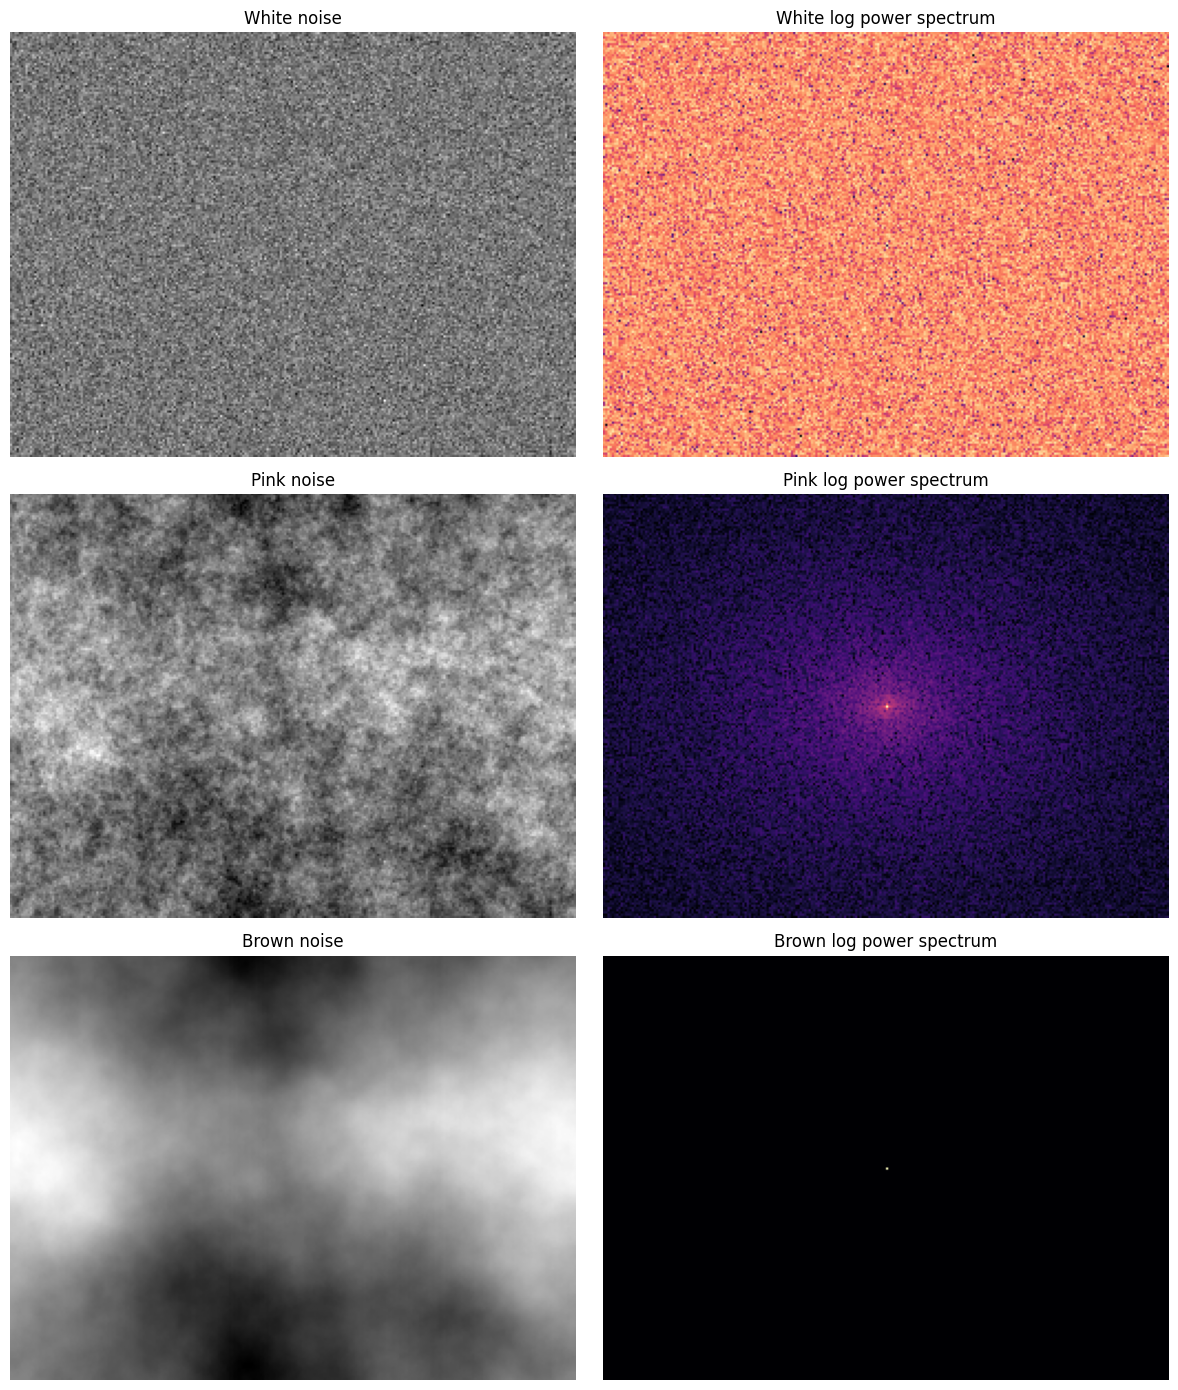

In [10]:
def radial_power_spectrum(noise: np.ndarray) -> np.ndarray:
    noise_4d, _ = ensure_4d(noise)
    spectrum = np.fft.fft2(noise_4d, axes=(-2, -1))
    power = np.abs(np.fft.fftshift(spectrum, axes=(-2, -1))) ** 2
    return np.squeeze(power)


def plot_noise_and_spectrum() -> None:
    white = np.random.default_rng(SEED).normal(size=(1, *CONFIG.image_size)).astype(GLOBAL_DTYPE)
    pink = spectral_noise_generator((1, *CONFIG.image_size), alpha=1.0)
    brown = spectral_noise_generator((1, *CONFIG.image_size), alpha=2.0)

    if plt is None:
        print("matplotlib is not available in this environment; skipping plots.")
        return

    fig, axes = plt.subplots(3, 2, figsize=(12, 14))
    for row, (name, noise) in enumerate((("White", white), ("Pink", pink), ("Brown", brown))):
        noise_4d, _ = ensure_4d(noise)
        sample = noise_4d[0, 0]
        power = radial_power_spectrum(noise)
        axes[row, 0].imshow(sample, cmap="gray")
        axes[row, 0].set_title(f"{name} noise")
        axes[row, 0].axis("off")
        axes[row, 1].imshow(np.log1p(power), cmap="magma")
        axes[row, 1].set_title(f"{name} log power spectrum")
        axes[row, 1].axis("off")
    fig.tight_layout()
    plt.show()


plot_noise_and_spectrum()

## 8. Export Poisoned Images Across an Epsilon Grid

## 9. Run Two-Epsilon Sweep with Attack Hook and Metric Logging

## 10. Export Results (Heatmaps, CSV, and Notebook Artifacts)

SER mean matrix shape: (6, 6)
CER mean matrix shape: (6, 6)


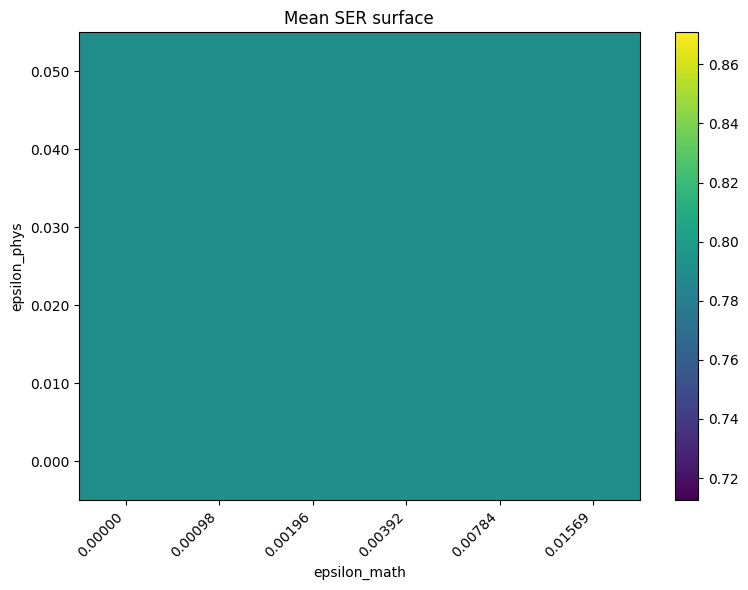

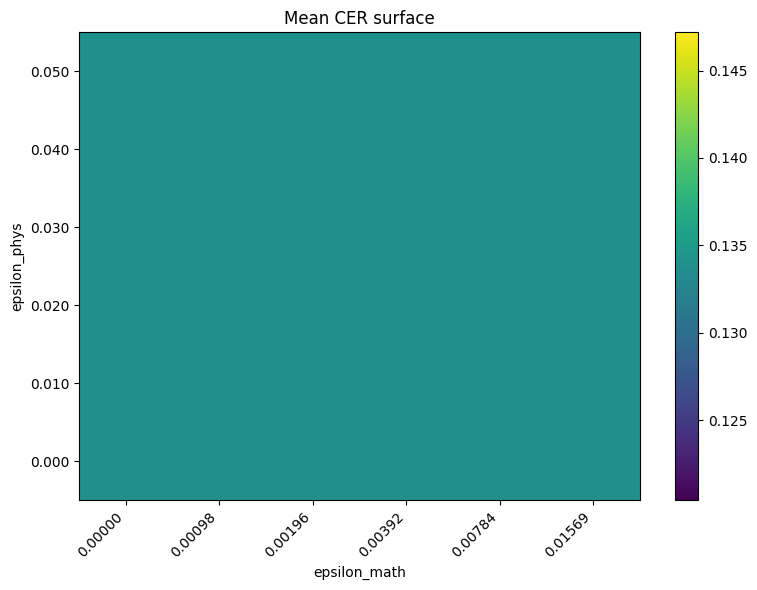

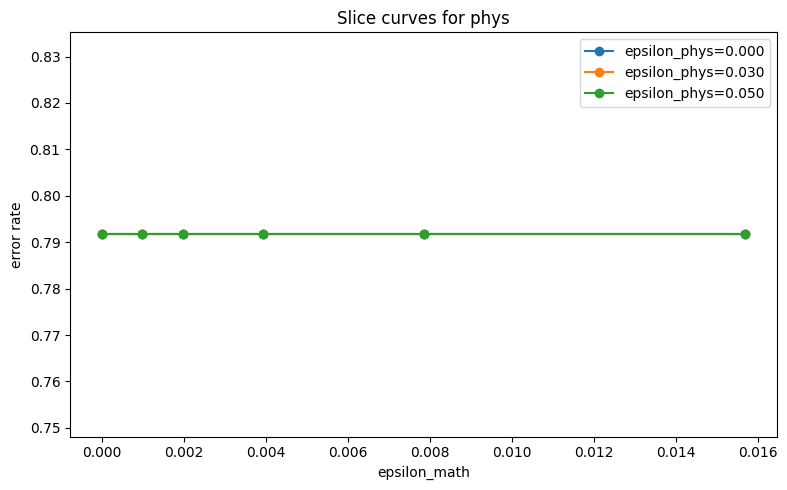

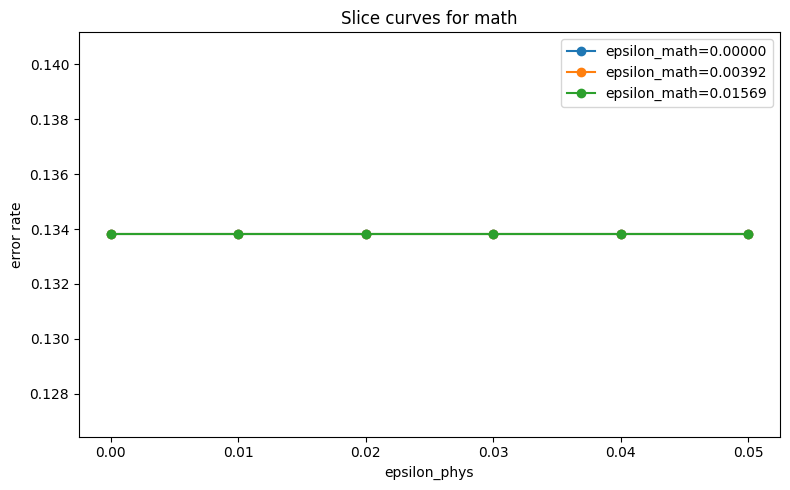

Artifacts written to: d:\Users\theda\Documents\dev\Projects\Uni\Semester 4\Artificial Intelligence\Synesthesia\attacks\artifacts\spectral_noise_injection


In [11]:
def attack_preprocess(
    x_corrupted: np.ndarray,
    y: Any,
    epsilon_math: float,
    attack_callable: Callable[[np.ndarray, Any, float], np.ndarray],
    *,
    alpha: float = 1.0,
    rng: np.random.Generator | None = None,
) -> np.ndarray:
    x_corrupted = np.asarray(x_corrupted, dtype=GLOBAL_DTYPE)
    if epsilon_math < 0.0:
        raise ValueError("epsilon_math must be non-negative")
    return attack_callable(x_corrupted, y, epsilon_math)


def dummy_attack(x_corrupted: np.ndarray, y: Any, epsilon_math: float) -> np.ndarray:
    centered = x_corrupted - x_corrupted.mean(axis=(-2, -1), keepdims=True)
    direction = np.sign(centered)
    if not np.any(direction):
        direction = spectral_noise_generator(x_corrupted.shape, alpha=1.0)
    return np.clip(x_corrupted + epsilon_math * direction, 0.0, 1.0).astype(GLOBAL_DTYPE)


def edit_distance(sequence_a: list[str], sequence_b: list[str]) -> int:
    rows = len(sequence_a) + 1
    cols = len(sequence_b) + 1
    dp = np.zeros((rows, cols), dtype=np.int32)
    dp[:, 0] = np.arange(rows)
    dp[0, :] = np.arange(cols)
    for row in range(1, rows):
        for col in range(1, cols):
            substitution_cost = 0 if sequence_a[row - 1] == sequence_b[col - 1] else 1
            dp[row, col] = min(
                dp[row - 1, col] + 1,
                dp[row, col - 1] + 1,
                dp[row - 1, col - 1] + substitution_cost,
            )
    return int(dp[-1, -1])


def symbol_error_rate(predicted: list[str], target: list[str]) -> float:
    return edit_distance(predicted, target) / max(len(target), 1)


def character_error_rate(predicted_text: str, target_text: str) -> float:
    return edit_distance(list(predicted_text), list(target_text)) / max(len(target_text), 1)


def dummy_model_predict_tokens(x: np.ndarray) -> list[str]:
    x_4d, _ = ensure_4d(x)
    image = x_4d[0, 0]
    quantiles = np.quantile(image, [0.2, 0.4, 0.6, 0.8])
    buckets = np.digitize(image.mean(axis=0), quantiles, right=False)
    return [f"tok_{int(value)}" for value in buckets[:12]]


def dummy_reference_tokens(index: int) -> list[str]:
    return [f"tok_{(index + offset) % 5}" for offset in range(12)]


def make_evaluation_dataset(sample_count: int = 4) -> list[dict[str, Any]]:
    dataset: list[dict[str, Any]] = []
    for index in range(sample_count):
        image = make_sample_score_tensor(*CONFIG.image_size)
        image = np.roll(image, shift=index * 7, axis=-1)
        image = np.roll(image, shift=index * 3, axis=-2)
        dataset.append(
            {
                "x": image,
                "y_tokens": dummy_reference_tokens(index),
                "y_text": " ".join(dummy_reference_tokens(index)),
            }
        )
    return dataset


def run_two_epsilon_sweep(
    dataset: list[dict[str, Any]],
    epsilon_phys_grid: tuple[float, ...],
    epsilon_math_grid: tuple[float, ...],
    attack_callable: Callable[[np.ndarray, Any, float], np.ndarray],
) -> dict[str, Any]:
    ser_mean = np.zeros((len(epsilon_phys_grid), len(epsilon_math_grid)), dtype=GLOBAL_DTYPE)
    ser_std = np.zeros_like(ser_mean)
    cer_mean = np.zeros_like(ser_mean)
    cer_std = np.zeros_like(ser_mean)
    rows: list[dict[str, Any]] = []

    for phys_index, epsilon_phys in enumerate(epsilon_phys_grid):
        for math_index, epsilon_math in enumerate(epsilon_math_grid):
            ser_scores: list[float] = []
            cer_scores: list[float] = []
            for sample_index, sample in enumerate(dataset):
                corrupted = spectral_noise_injection(sample["x"], epsilon_phys=epsilon_phys, alpha=CONFIG.alpha)
                adversarial = attack_preprocess(corrupted, sample["y_tokens"], epsilon_math, attack_callable)
                predicted_tokens = dummy_model_predict_tokens(adversarial)
                predicted_text = " ".join(predicted_tokens)
                ser_scores.append(symbol_error_rate(predicted_tokens, sample["y_tokens"]))
                cer_scores.append(character_error_rate(predicted_text, sample["y_text"]))
                rows.append(
                    {
                        "epsilon_phys": float(epsilon_phys),
                        "epsilon_math": float(epsilon_math),
                        "sample_index": sample_index,
                        "ser": ser_scores[-1],
                        "cer": cer_scores[-1],
                    }
                )
            ser_mean[phys_index, math_index] = float(np.mean(ser_scores))
            ser_std[phys_index, math_index] = float(np.std(ser_scores, ddof=0))
            cer_mean[phys_index, math_index] = float(np.mean(cer_scores))
            cer_std[phys_index, math_index] = float(np.std(cer_scores, ddof=0))

    return {
        "ser_mean": ser_mean,
        "ser_std": ser_std,
        "cer_mean": cer_mean,
        "cer_std": cer_std,
        "rows": rows,
    }


def plot_heatmap(matrix: np.ndarray, title: str, epsilon_phys_grid: tuple[float, ...], epsilon_math_grid: tuple[float, ...]) -> None:
    if plt is None:
        print(f"matplotlib unavailable, skipping {title}")
        return
    fig, ax = plt.subplots(figsize=(8, 6))
    image = ax.imshow(matrix, origin="lower", aspect="auto", cmap="viridis")
    ax.set_xticks(range(len(epsilon_math_grid)))
    ax.set_xticklabels([f"{value:.5f}" for value in epsilon_math_grid], rotation=45, ha="right")
    ax.set_yticks(range(len(epsilon_phys_grid)))
    ax.set_yticklabels([f"{value:.3f}" for value in epsilon_phys_grid])
    ax.set_xlabel("epsilon_math")
    ax.set_ylabel("epsilon_phys")
    ax.set_title(title)
    fig.colorbar(image, ax=ax)
    fig.tight_layout()
    plt.show()


def plot_slice_curves(matrix: np.ndarray, epsilon_phys_grid: tuple[float, ...], epsilon_math_grid: tuple[float, ...], axis: str) -> None:
    if plt is None:
        return
    fig, ax = plt.subplots(figsize=(8, 5))
    if axis == "phys":
        indices = [0, len(epsilon_phys_grid) // 2, len(epsilon_phys_grid) - 1]
        for index in indices:
            ax.plot(epsilon_math_grid, matrix[index], marker="o", label=f"epsilon_phys={epsilon_phys_grid[index]:.3f}")
        ax.set_xlabel("epsilon_math")
    else:
        indices = [0, len(epsilon_math_grid) // 2, len(epsilon_math_grid) - 1]
        for index in indices:
            ax.plot(epsilon_phys_grid, matrix[:, index], marker="o", label=f"epsilon_math={epsilon_math_grid[index]:.5f}")
        ax.set_xlabel("epsilon_phys")
    ax.set_ylabel("error rate")
    ax.set_title(f"Slice curves for {axis}")
    ax.legend()
    fig.tight_layout()
    plt.show()


workspace_root = next((parent for parent in [Path.cwd(), *Path.cwd().parents] if (parent / "pyproject.toml").exists()), Path.cwd())
artifact_dir = workspace_root / "attacks" / "artifacts" / "spectral_noise_injection"
artifact_dir.mkdir(parents=True, exist_ok=True)

evaluation_dataset = make_evaluation_dataset(sample_count=4)
results = run_two_epsilon_sweep(
    evaluation_dataset,
    CONFIG.epsilon_phys_grid,
    CONFIG.epsilon_math_grid,
    dummy_attack,
)

print("SER mean matrix shape:", results["ser_mean"].shape)
print("CER mean matrix shape:", results["cer_mean"].shape)

plot_heatmap(results["ser_mean"], "Mean SER surface", CONFIG.epsilon_phys_grid, CONFIG.epsilon_math_grid)
plot_heatmap(results["cer_mean"], "Mean CER surface", CONFIG.epsilon_phys_grid, CONFIG.epsilon_math_grid)
plot_slice_curves(results["ser_mean"], CONFIG.epsilon_phys_grid, CONFIG.epsilon_math_grid, axis="phys")
plot_slice_curves(results["cer_mean"], CONFIG.epsilon_phys_grid, CONFIG.epsilon_math_grid, axis="math")

if pd is not None:
    summary_rows = []
    for phys_index, epsilon_phys in enumerate(CONFIG.epsilon_phys_grid):
        for math_index, epsilon_math in enumerate(CONFIG.epsilon_math_grid):
            summary_rows.append(
                {
                    "epsilon_phys": epsilon_phys,
                    "epsilon_math": epsilon_math,
                    "mean_ser": float(results["ser_mean"][phys_index, math_index]),
                    "std_ser": float(results["ser_std"][phys_index, math_index]),
                    "mean_cer": float(results["cer_mean"][phys_index, math_index]),
                    "std_cer": float(results["cer_std"][phys_index, math_index]),
                    "sample_count": len(evaluation_dataset),
                }
            )
    summary_frame = pd.DataFrame(summary_rows)
    summary_frame.to_csv(artifact_dir / "spectral_noise_sweep_summary.csv", index=False)
else:
    import csv

    with (artifact_dir / "spectral_noise_sweep_summary.csv").open("w", newline="", encoding="utf-8") as handle:
        writer = csv.DictWriter(
            handle,
            fieldnames=["epsilon_phys", "epsilon_math", "mean_ser", "std_ser", "mean_cer", "std_cer", "sample_count"],
        )
        writer.writeheader()
        for phys_index, epsilon_phys in enumerate(CONFIG.epsilon_phys_grid):
            for math_index, epsilon_math in enumerate(CONFIG.epsilon_math_grid):
                writer.writerow(
                    {
                        "epsilon_phys": epsilon_phys,
                        "epsilon_math": epsilon_math,
                        "mean_ser": float(results["ser_mean"][phys_index, math_index]),
                        "std_ser": float(results["ser_std"][phys_index, math_index]),
                        "mean_cer": float(results["cer_mean"][phys_index, math_index]),
                        "std_cer": float(results["cer_std"][phys_index, math_index]),
                        "sample_count": len(evaluation_dataset),
                    }
                )

metadata = {
    "seed": SEED,
    "config": asdict(CONFIG),
    "dataset_size": len(evaluation_dataset),
}

import json

(artifact_dir / "spectral_noise_config.json").write_text(json.dumps(metadata, indent=2), encoding="utf-8")
np.save(artifact_dir / "ser_mean.npy", results["ser_mean"])
np.save(artifact_dir / "cer_mean.npy", results["cer_mean"])
np.save(artifact_dir / "ser_std.npy", results["ser_std"])
np.save(artifact_dir / "cer_std.npy", results["cer_std"])

print(f"Artifacts written to: {artifact_dir}")

## 8. Poison the Raster Dataset and Build a Reference Manifest

In [20]:
def discover_raster_images(root: Path) -> list[Path]:
    if not root.exists():
        raise FileNotFoundError(f"Raster image root does not exist: {root}")
    return sorted(
        path
        for path in root.rglob("*")
        if path.is_file() and path.suffix.lower() in SUPPORTED_IMAGE_SUFFIXES
    )


def load_raster_image(path: Path) -> tuple[np.ndarray, str]:
    from PIL import Image

    # Force-load as grayscale because HOMR preprocessing converts images to grayscale.
    image = Image.open(path).convert("L")
    array = np.asarray(image, dtype=GLOBAL_DTYPE)
    return (array / 255.0)[None, :, :], "L"


def save_raster_image(array: np.ndarray, path: Path, mode: str) -> None:
    from PIL import Image

    path.parent.mkdir(parents=True, exist_ok=True)
    clipped = np.clip(np.asarray(array, dtype=GLOBAL_DTYPE), 0.0, 1.0)
    if clipped.ndim == 2:
        pixels = (clipped * 255.0).round().astype(np.uint8)
        Image.fromarray(pixels, mode="L").save(path)
        return
    if clipped.ndim == 3 and clipped.shape[0] == 1:
        pixels = (clipped[0] * 255.0).round().astype(np.uint8)
        Image.fromarray(pixels, mode="L").save(path)
        return
    if clipped.ndim == 3:
        pixels = np.transpose((clipped * 255.0).round().astype(np.uint8), (1, 2, 0))
        Image.fromarray(pixels, mode="RGB").save(path)
        return
    raise ValueError(f"Unsupported tensor shape for saving: {clipped.shape}")


def find_reference_xml(image_path: Path) -> Path | None:
    relative_image = image_path.relative_to(IMAGE_ROOT)
    for suffix in SUPPORTED_XML_SUFFIXES:
        candidate = (MXL_ROOT / relative_image).with_suffix(suffix)
        if candidate.exists():
            return candidate
    for suffix in SUPPORTED_XML_SUFFIXES:
        matches = sorted(path for path in MXL_ROOT.rglob(f"{image_path.stem}{suffix}") if path.is_file())
        if matches:
            return matches[0]
    return None


def export_poisoned_dataset(
    epsilon_phys_grid: tuple[float, ...],
    alpha: float,
    *,
    limit: int | None = None,
) -> list[dict[str, Any]]:
    source_images = discover_raster_images(IMAGE_ROOT)
    if limit is not None:
        source_images = source_images[:limit]

    rng = np.random.default_rng(SEED)
    manifest_rows: list[dict[str, Any]] = []

    def write_manifest_table(path: Path, rows: list[dict[str, Any]]) -> None:
        if not rows:
            return
        if pd is not None:
            pd.DataFrame(rows).to_csv(path, index=False)
            return
        import csv

        with path.open("w", newline="", encoding="utf-8") as handle:
            writer = csv.DictWriter(handle, fieldnames=list(rows[0].keys()))
            writer.writeheader()
            writer.writerows(rows)

    PREDICTED_XML_ROOT.mkdir(parents=True, exist_ok=True)
    for epsilon_phys in epsilon_phys_grid:
        epsilon_tag = f"{epsilon_phys:.4f}".replace(".", "p")
        output_root = POISONED_IMAGE_ROOT / f"eps_{epsilon_tag}"
        output_root.mkdir(parents=True, exist_ok=True)

        epsilon_rows: list[dict[str, Any]] = []
        for index, source_path in enumerate(source_images):
            image_tensor, mode = load_raster_image(source_path)
            poisoned_tensor = spectral_noise_injection(
                image_tensor,
                epsilon_phys=epsilon_phys,
                alpha=alpha,
                eta=CONFIG.eta,
                epsilon_num=CONFIG.epsilon_num,
                white_noise_scale=CONFIG.white_noise_scale,
                rng=rng,
            )
            relative_image_path = source_path.relative_to(IMAGE_ROOT)
            poisoned_path = output_root / relative_image_path
            save_raster_image(poisoned_tensor, poisoned_path, mode)

            reference_xml = find_reference_xml(source_path)
            row = {
                "index": index,
                "source_image": str(source_path.relative_to(WORKSPACE_ROOT)),
                "poisoned_image": str(poisoned_path.relative_to(WORKSPACE_ROOT)),
                "reference_xml": str(reference_xml.relative_to(WORKSPACE_ROOT)) if reference_xml is not None else "",
                "epsilon_phys": float(epsilon_phys),
                "alpha": float(alpha),
                "mode": mode,
            }
            manifest_rows.append(row)
            epsilon_rows.append(row)

        manifest_path = ATTACK_ARTIFACT_ROOT / f"poisoned_manifest_eps_{epsilon_tag}.csv"
        write_manifest_table(manifest_path, epsilon_rows)

    combined_manifest_path = ATTACK_ARTIFACT_ROOT / "poisoned_manifest_all.csv"
    write_manifest_table(combined_manifest_path, manifest_rows)

    metadata = {
        "seed": SEED,
        "epsilon_phys_grid": [float(value) for value in epsilon_phys_grid],
        "alpha": float(alpha),
        "source_image_count": len(source_images),
        "output_root": str(POISONED_IMAGE_ROOT.relative_to(WORKSPACE_ROOT)),
        "poisoned_image_root": str(POISONED_IMAGE_ROOT.relative_to(WORKSPACE_ROOT)),
        "reference_root": str(MXL_ROOT.relative_to(WORKSPACE_ROOT)),
    }
    import json

    (ATTACK_ARTIFACT_ROOT / "poisoned_manifest_metadata.json").write_text(json.dumps(metadata, indent=2), encoding="utf-8")
    return manifest_rows


smoke_manifest = export_poisoned_dataset(CONFIG.epsilon_phys_grid, alpha=CONFIG.alpha, limit=1)
print(f"Wrote {len(smoke_manifest)} poisoned images across {len(CONFIG.epsilon_phys_grid)} epsilons")
print(smoke_manifest[0] if smoke_manifest else "No images found in dataset/images")

Wrote 6 poisoned images across 6 epsilons
{'index': 0, 'source_image': 'dataset\\images\\Qmb51KyRrjKZX8QnCdGLV66zco7CEa7dsV3HksuJY36qHX-1.png', 'poisoned_image': 'attacks\\artifacts\\spectral_noise_injection\\poisoned_images\\eps_0p0000\\Qmb51KyRrjKZX8QnCdGLV66zco7CEa7dsV3HksuJY36qHX-1.png', 'reference_xml': '', 'epsilon_phys': 0.0, 'alpha': 1.0, 'mode': 'L'}
